# AI / Machine Learning — Complete Project Notebook

**Covering all core algorithms from the syllabus, end-to-end.**

This single notebook walks through the full machine-learning workflow and implements every
classic algorithm in the course on real, built-in datasets — so it runs anywhere with
**no external files**.

| Section | Topic | Algorithm(s) | Project theme |
|---|---|---|---|
| 1 | Data exploration | pandas, seaborn | — |
| 2 | Preprocessing | scaling, encoding, split | — |
| 3 | Regression | Linear, RandomForest, GradientBoosting | **Salary Prediction** |
| 4 | Classification | Logistic, KNN, DecisionTree, RandomForest | **Medical Diagnosis** |
| 5 | Evaluation | accuracy, precision, recall, F1, ROC-AUC, confusion matrix | — |
| 6 | Ensembles | Bagging, RandomForest, AdaBoost, GradientBoosting | — |
| 7 | Tuning | GridSearchCV + cross-validation | — |
| 8 | Clustering | K-Means, Hierarchical | **Customer Segmentation** |
| 9 | Dimensionality | PCA | — |
| 10 | NLP | TF-IDF + Naive Bayes | **Spam / Fake-news Detection** |

> Run top-to-bottom with **Shift + Enter**.

## Setup

If any import fails, install the libraries once by running this in a cell:

`!pip install numpy pandas scikit-learn matplotlib seaborn scipy`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="whitegrid")
np.random.seed(42)          # reproducible results
print("Setup complete.")

Setup complete.


# 1. Data Loading & Exploration

We start with the classic **Iris** dataset (flower measurements) to practise exploration.
Always look at your data before modelling.

In [2]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df = iris.frame                      # a pandas DataFrame
df['species'] = iris.target_names[iris.target]
print("Shape:", df.shape)
df.head()

Shape: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


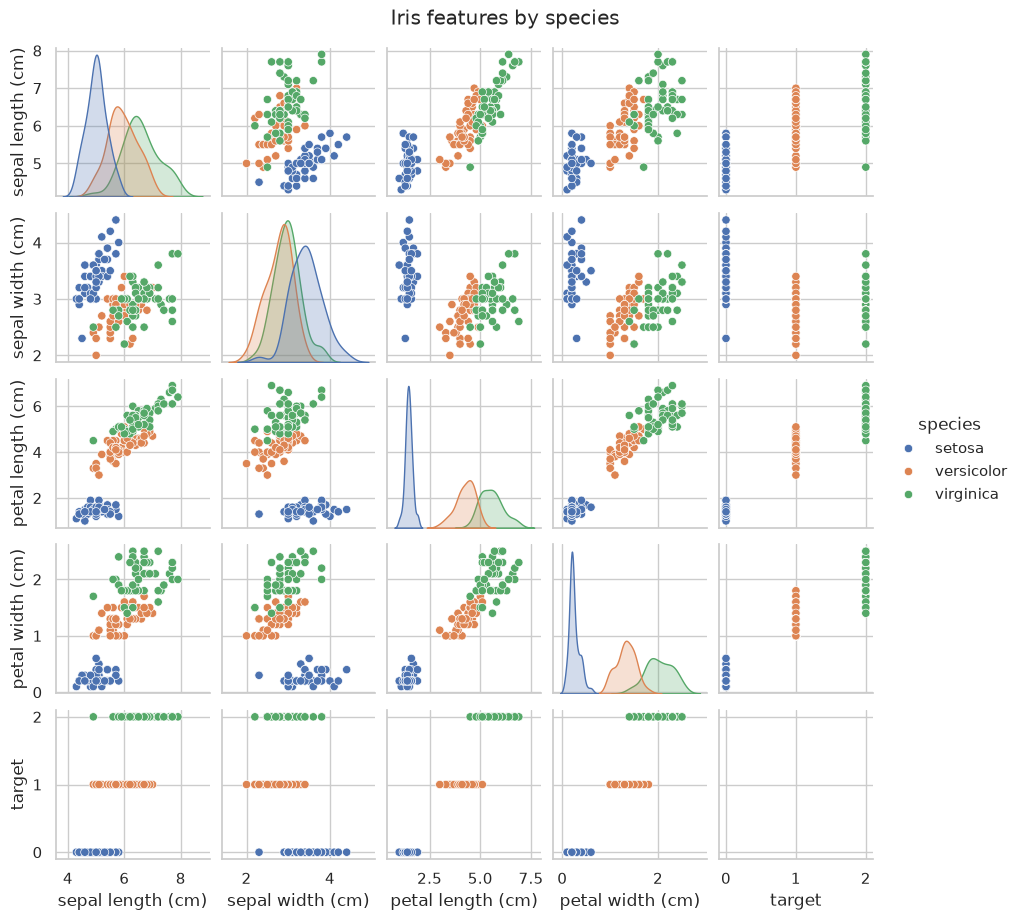

In [4]:
# How many of each species?
print(df['species'].value_counts())

# Visualise relationships between features
sns.pairplot(df, hue='species', height=1.8)
plt.suptitle("Iris features by species", y=1.02)
plt.show()

# 2. Data Preprocessing

Real data needs cleaning. We demonstrate the four key steps:
**missing values, encoding, scaling, and the train-test split.**

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Missing values (demo): create one, then fill it with the column mean
demo = df.copy()
demo.loc[0, 'sepal length (cm)'] = np.nan
print("Missing before:", demo.isnull().sum().sum())
demo['sepal length (cm)'] = demo['sepal length (cm)'].fillna(demo['sepal length (cm)'].mean())
print("Missing after :", demo.isnull().sum().sum())

# --- Encoding: turn text labels into numbers
from sklearn.preprocessing import LabelEncoder
y = LabelEncoder().fit_transform(df['species'])      # 0,1,2
X = df.drop(columns=['species', 'target'])

# --- Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# --- Scaling: bring all features to a similar range
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train size:", X_train.shape, " Test size:", X_test.shape)

Missing before: 1
Missing after : 0
Train size: (120, 4)  Test size: (30, 4)


# 3. Regression — Salary Prediction

**Regression predicts a number.** We build a realistic synthetic salary dataset
(experience, test score, interview score -> salary) and compare three models.

In [6]:
# --- Build a synthetic but realistic salary dataset
n = 300
experience = np.random.randint(0, 20, n)
test_score = np.random.randint(40, 100, n)
interview = np.random.randint(1, 10, n)
salary = (25000
          + experience * 2500
          + test_score * 300
          + interview * 1500
          + np.random.normal(0, 4000, n))      # noise

salary_df = pd.DataFrame({
    'experience': experience,
    'test_score': test_score,
    'interview_score': interview,
    'salary': salary.round(0),
})
salary_df.head()

,experience,test_score,interview_score,salary
0,6,64,4,67313.0
1,19,81,5,105130.0
2,14,70,4,95173.0
3,10,93,5,91878.0
4,7,97,7,85832.0


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

Xr = salary_df[['experience', 'test_score', 'interview_score']]
yr = salary_df['salary']
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest":     RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

for name, model in models.items():
    model.fit(Xr_tr, yr_tr)
    pred = model.predict(Xr_te)
    print(f"{name:18}  MAE = {mean_absolute_error(yr_te, pred):8.0f}   R2 = {r2_score(yr_te, pred):.3f}")

Linear Regression   MAE =     3556   R2 = 0.936
Random Forest       MAE =     4073   R2 = 0.922
Gradient Boosting   MAE =     3914   R2 = 0.923


In [8]:
# Predict salary for a new candidate: 5 yrs exp, score 80, interview 7
best = models["Gradient Boosting"]
new_candidate = [[5, 80, 7]]
print("Predicted salary:", round(best.predict(new_candidate)[0], 0))

Predicted salary: 73292.0


/home/zeus/programming/python/venv/lib64/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


# 4. Classification — Medical Diagnosis

**Classification predicts a category.** We use the **Breast Cancer** dataset
(malignant vs benign) and compare four classic algorithms.

In [9]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

cancer = load_breast_cancer()
Xc, yc = cancer.data, cancer.target     # target: 0 = malignant, 1 = benign

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    Xc, yc, test_size=0.2, random_state=42, stratify=yc)

# scale (important for Logistic Regression and KNN)
sc = StandardScaler()
Xc_tr_s = sc.fit_transform(Xc_tr)
Xc_te_s = sc.transform(Xc_te)

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "K-Nearest Neighbours": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree":        DecisionTreeClassifier(random_state=42),
    "Random Forest":        RandomForestClassifier(n_estimators=100, random_state=42),
}

for name, clf in classifiers.items():
    clf.fit(Xc_tr_s, yc_tr)
    acc = clf.score(Xc_te_s, yc_te)
    print(f"{name:22}  accuracy = {acc:.3f}")

Logistic Regression     accuracy = 0.982
K-Nearest Neighbours    accuracy = 0.956
Decision Tree           accuracy = 0.912
Random Forest           accuracy = 0.956


# 5. Model Evaluation — beyond accuracy

Accuracy alone can mislead. We look at **precision, recall, F1, the confusion matrix,
and the ROC-AUC** for our best classifier.

In [10]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

clf = classifiers["Random Forest"]
y_pred = clf.predict(Xc_te_s)
y_proba = clf.predict_proba(Xc_te_s)[:, 1]

print(classification_report(yc_te, y_pred, target_names=cancer.target_names))
print("ROC-AUC:", round(roc_auc_score(yc_te, y_proba), 3))

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

ROC-AUC: 0.994


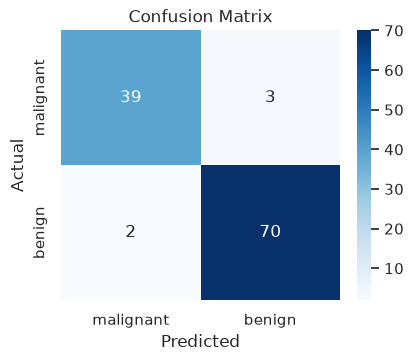

In [11]:
# Confusion matrix as a heatmap
cm = confusion_matrix(yc_te, y_pred)
plt.figure(figsize=(4.5, 3.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
plt.show()

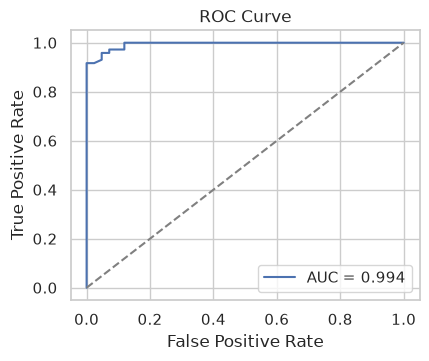

In [12]:
# ROC curve
fpr, tpr, _ = roc_curve(yc_te, y_proba)
plt.figure(figsize=(4.5, 3.5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(yc_te, y_proba):.3f}")
plt.plot([0, 1], [0, 1], '--', color='grey')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve"); plt.legend()
plt.show()

# 6. Ensemble Methods

**Ensembles combine many models for better accuracy.** We compare bagging and boosting.

In [13]:
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier,
                              AdaBoostClassifier, GradientBoostingClassifier)
from sklearn.model_selection import cross_val_score

ensembles = {
    "Bagging":           BaggingClassifier(n_estimators=50, random_state=42),
    "Random Forest":     RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost":          AdaBoostClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

for name, model in ensembles.items():
    scores = cross_val_score(model, Xc_tr_s, yc_tr, cv=5)
    print(f"{name:18}  CV accuracy = {scores.mean():.3f} (+/- {scores.std():.3f})")

Bagging             CV accuracy = 0.954 (+/- 0.019)
Random Forest       CV accuracy = 0.954 (+/- 0.023)
AdaBoost            CV accuracy = 0.974 (+/- 0.022)
Gradient Boosting   CV accuracy = 0.956 (+/- 0.014)


# 7. Hyperparameter Tuning

**Grid Search** tries many settings with **cross-validation** and keeps the best combo.

In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
}
grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid, cv=5, n_jobs=-1)
grid.fit(Xc_tr_s, yc_tr)

print("Best settings :", grid.best_params_)
print("Best CV score :", round(grid.best_score_, 3))
print("Test accuracy :", round(grid.score(Xc_te_s, yc_te), 3))

Best settings : {'max_depth': None, 'n_estimators': 200}
Best CV score : 0.96
Test accuracy : 0.956


# 8. Unsupervised Learning — Customer Segmentation

**Clustering groups data without labels.** We create customers (income vs spending)
and group them with **K-Means**, then compare with **Hierarchical clustering**.

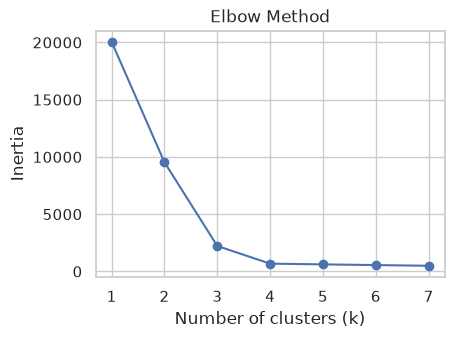

In [15]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# synthetic customers: annual income vs spending score
X_cust, _ = make_blobs(n_samples=300, centers=4, cluster_std=1.1, random_state=42)

# Elbow method: find a good number of clusters
inertia = []
for k in range(1, 8):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_cust)
    inertia.append(km.inertia_)

plt.figure(figsize=(4.5, 3.2))
plt.plot(range(1, 8), inertia, 'o-')
plt.xlabel("Number of clusters (k)"); plt.ylabel("Inertia")
plt.title("Elbow Method"); plt.show()

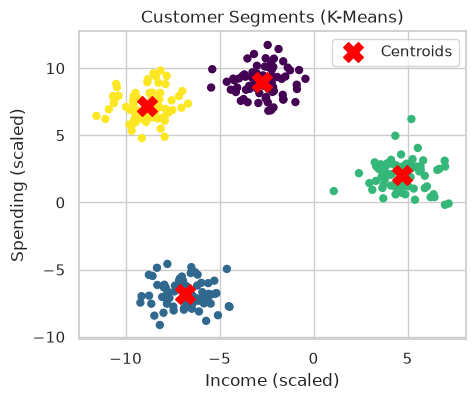

In [16]:
# Fit K-Means with k=4 and plot the segments
km = KMeans(n_clusters=4, n_init=10, random_state=42)
labels = km.fit_predict(X_cust)

plt.figure(figsize=(5, 4))
plt.scatter(X_cust[:, 0], X_cust[:, 1], c=labels, cmap='viridis', s=25)
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            c='red', marker='X', s=200, label='Centroids')
plt.xlabel("Income (scaled)"); plt.ylabel("Spending (scaled)")
plt.title("Customer Segments (K-Means)"); plt.legend(); plt.show()

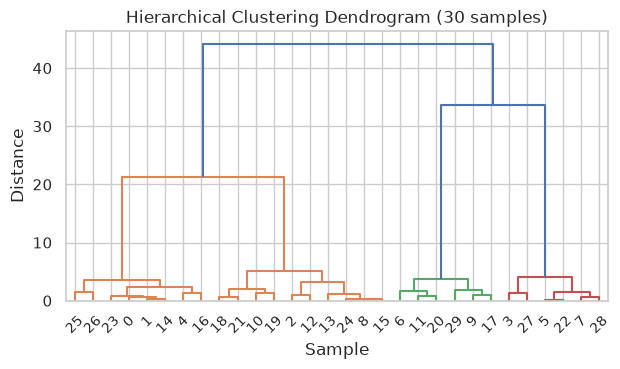

Hierarchical clusters found: 4


In [17]:
# Hierarchical clustering: dendrogram + AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

linked = linkage(X_cust[:30], method='ward')   # small sample for a clear tree
plt.figure(figsize=(7, 3.5))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram (30 samples)")
plt.xlabel("Sample"); plt.ylabel("Distance"); plt.show()

agg = AgglomerativeClustering(n_clusters=4)
agg_labels = agg.fit_predict(X_cust)
print("Hierarchical clusters found:", len(np.unique(agg_labels)))

# 9. Dimensionality Reduction — PCA

**PCA** squeezes many columns into a few while keeping most information —
great for visualising high-dimensional data. We reduce the 30-feature cancer data to 2D.

Variance explained by 2 components: [0.443 0.19 ]  total = 0.632


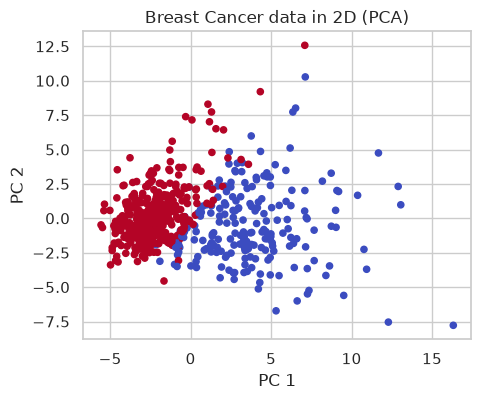

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(StandardScaler().fit_transform(Xc))

print("Variance explained by 2 components:",
      np.round(pca.explained_variance_ratio_, 3),
      " total =", round(pca.explained_variance_ratio_.sum(), 3))

plt.figure(figsize=(5, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=yc, cmap='coolwarm', s=20)
plt.xlabel("PC 1"); plt.ylabel("PC 2")
plt.title("Breast Cancer data in 2D (PCA)"); plt.show()

# 10. NLP — Spam / Fake-news Style Text Classification

**Turn text into numbers with TF-IDF, then classify with Naive Bayes.**
We use a small built-in message set so it runs instantly.

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

# tiny labelled dataset: 1 = spam/fake, 0 = genuine
texts = [
    "Win a FREE iPhone now, click this link!",
    "Congratulations! You won a lottery of $1000000",
    "Claim your free prize money urgently",
    "Limited offer, buy now and get 90% discount",
    "Breaking: miracle cure discovered, doctors hate it",
    "Hi, are we still meeting for lunch tomorrow?",
    "Please find attached the project report",
    "The quarterly results look good this year",
    "Can you review my code before the demo?",
    "Reminder: your dentist appointment is on Monday",
]
labels = [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]

model = make_pipeline(TfidfVectorizer(), MultinomialNB())
model.fit(texts, labels)

# test on new messages
tests = ["Free money, claim your prize now!",
         "Let's schedule the team meeting for Friday"]
preds = model.predict(tests)
for t, p in zip(tests, preds):
    print(f"[{'SPAM/FAKE' if p == 1 else 'GENUINE  '}]  {t}")

[SPAM/FAKE]  Free money, claim your prize now!
[GENUINE  ]  Let's schedule the team meeting for Friday


# Conclusion & Next Steps

**What we built in one notebook:**
- A full ML workflow: explore -> preprocess -> train -> evaluate -> tune.
- **Regression** (Salary Prediction) with Linear, Random Forest, Gradient Boosting.
- **Classification** (Medical Diagnosis) with Logistic Regression, KNN, Decision Tree, Random Forest.
- **Proper evaluation**: precision, recall, F1, confusion matrix, ROC-AUC.
- **Ensembles** (Bagging, Random Forest, AdaBoost, Gradient Boosting) + cross-validation.
- **Hyperparameter tuning** with GridSearchCV.
- **Clustering** (K-Means + Hierarchical) for Customer Segmentation.
- **PCA** for dimensionality reduction and visualisation.
- **NLP** text classification (TF-IDF + Naive Bayes) for Spam / Fake-news detection.

**Extend it yourself:**
1. Replace a built-in dataset with a real CSV (`pd.read_csv(...)`).
2. Try **XGBoost** (`pip install xgboost`) and compare to Gradient Boosting.
3. Add a **Deep Learning** model with TensorFlow/Keras for the CNN digit-recognition project
   (`pip install tensorflow`).
4. For Computer Vision, install **OpenCV** (`pip install opencv-python`) and try face detection.

In [20]:
# Your experiments here